# 02 -- SHAP Analysis

Explain model predictions using SHAP values.

**Covers**: global importance (beeswarm), local patient-level explanations, interaction dependence plots.

## What is a SHAP value?

For one patient and one feature, the SHAP value is how much that feature moved this model's prediction, in the model's own log-odds units, away from a baseline average prediction. Positive = pushed toward higher mortality risk; negative = pushed toward lower risk. Every patient's SHAP values across all features, plus the baseline, add up exactly to their final predicted log-odds -- that is what makes it an *additive* explanation rather than a rough approximation.

Two levels are used below:
- **Global** (section 4): average |SHAP value| per feature across every patient -- which features matter most overall.
- **Local** (section 5): SHAP values for one specific patient -- why the model predicted what it did for *them* specifically, which can differ from the global ranking.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.extract import load_whas500
from src.data.transform import prepare_whas500_for_ml
from src.models.train import load_model
from src.models.shap_explainer import (
    build_explainer, compute_shap_values,
    global_feature_importance, local_explanation, interaction_analysis
)
from src.visualisation.plots import (
    plot_shap_summary, plot_shap_waterfall, plot_shap_dependence
)
from src.utils.config import WHAS500Config
print('Setup OK')

Setup OK


## 2. Load Model and Data

In [2]:
whas_raw = load_whas500()
X_train, X_test, y_train, y_test, scaler = prepare_whas500_for_ml(whas_raw)

# Use Logistic Regression -- best AUC on WHAS500 (0.880 vs XGBoost's 0.853),
# and its coefficients are directly interpretable, which matters for a
# clinical-facing tool.
model = load_model('logistic_regression', 'whas500')
print(f'Model loaded. Test set: {len(X_test)} patients, {y_test.mean():.1%} mortality')

2026-07-18 12:32:08 | INFO     | src.data.extract                    | WHAS500 loaded (bundled via scikit-survival): 500 patients, 16 columns, 43.0% died during follow-up


2026-07-18 12:32:08 | INFO     | src.data.transform                  | WHAS500 cleaned: 500 patients, 43.0% mortality


2026-07-18 12:32:08 | INFO     | src.data.features                   | WHAS500 encoded: 14 features


2026-07-18 12:32:09 | INFO     | src.data.transform                  | Train/test split: 400 train, 100 test (stratified, seed=42)


2026-07-18 12:32:09 | INFO     | src.data.transform                  | Class balance — train: 43.0% positive, test: 43.0% positive


2026-07-18 12:32:09 | INFO     | src.data.transform                  | Features scaled: 5 numeric columns standardised


Model loaded. Test set: 100 patients, 43.0% mortality


## 3. Build SHAP Explainer and Compute Values

In [3]:
explainer   = build_explainer(model, X_train, 'logistic_regression')
shap_values = compute_shap_values(explainer, X_test, 'logistic_regression')
print(f'SHAP values shape: {shap_values.shape}')

2026-07-18 12:32:09 | INFO     | src.models.shap_explainer           | Using LinearExplainer for logistic_regression


2026-07-18 12:32:09 | INFO     | src.models.shap_explainer           | Computing SHAP values for logistic_regression (100 samples, 14 features)...


2026-07-18 12:32:09 | INFO     | src.models.shap_explainer           | SHAP values computed: shape=(100, 14), mean_abs=0.2105


SHAP values shape: (100, 14)


## 4. Global Feature Importance

In [4]:
importance = global_feature_importance(shap_values, list(X_test.columns))
print('Top 10 features by mean |SHAP|:')
for feat in importance:
    bar = '█' * int(feat['mean_abs_shap'] * 300)
    print(f"  {feat['rank']:2d}. {feat['feature']:<20} {feat['mean_abs_shap']:.4f}  {bar}")

Top 10 features by mean |SHAP|:
   1. age                  0.7899  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2. chf                  0.4992  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   3. sysbp                0.3701  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████
   4. hr                   0.2973  █████████████████████████████████████████████████████████████████████████████████████████
   5. pulse_pressure       0.2473  ██████████████████████████████████████████████████████████████████████████
   6. mitype               0.1996  ███████████████████████████████████████████████████████████
   7. afb                  0.1251 

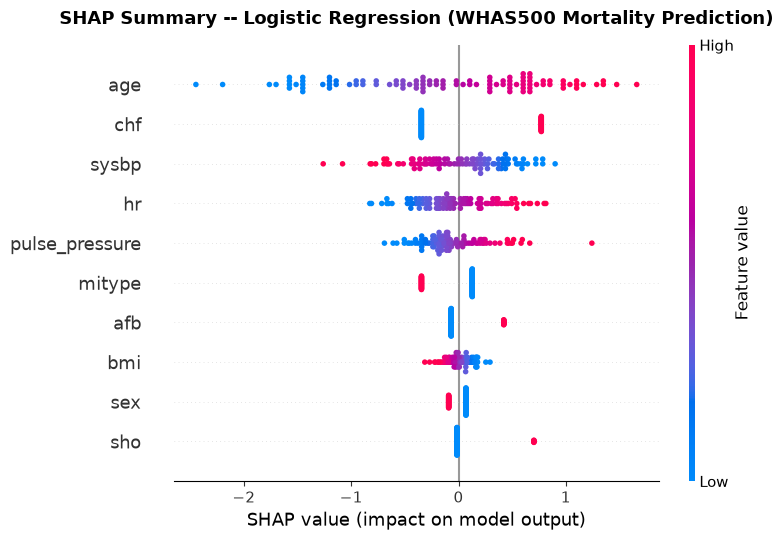

In [5]:
# SHAP beeswarm plot -- the standard global importance visualisation
plot_shap_summary(shap_values, X_test, list(X_test.columns),
                  title='SHAP Summary -- Logistic Regression (WHAS500 Mortality Prediction)',
                  plot_type='dot')
plt.show()

**How to read this plot**: each dot is one patient in the test set.
Its horizontal position is that patient's SHAP value for the row's
feature -- how far right (higher predicted mortality risk) or left
(lower risk) that specific feature pushed that specific patient's
prediction. Colour is the patient's actual value for that feature
(red = high, blue = low). Rows are sorted by overall importance
(top = most influential across all patients).

Reading the actual result above: **age** is the top feature, and its
colouring is a clean gradient -- red (older) dots sit almost entirely
on the right (raises risk), blue (younger) dots sit on the left
(lowers risk). That is the strongest, most consistent signal in the
model. **chf** (heart failure) is second, and being binary its dots
split into two tight clusters rather than a gradient: red (chf=1) on
the right, blue (chf=0) on the left -- a clean, unambiguous risk
factor. Features further down the list (mitype, sex, miord) have SHAP
values clustered close to zero, meaning they barely move any
individual patient's prediction relative to age and chf.

## 5. Local Patient Explanation

In [6]:
# Find the highest-risk patient in the test set
high_risk_idx = int(model.predict_proba(X_test)[:, 1].argmax())
expl = local_explanation(explainer, X_test, list(X_test.columns), patient_idx=high_risk_idx)

print(f'Patient {high_risk_idx}: predicted mortality risk = {expl["prediction"]:.1%}')
print(f'Baseline (mean prediction): {expl["base_probability"]:.1%}')
print()
print('Top risk factors:')
for c in expl['top_risk_factors']:
    print(f"  {c['feature']:<20} value={c['value']:.2f}  SHAP=+{c['shap_value']:.4f}")
print()
print('Protective factors:')
for c in expl['top_protective']:
    print(f"  {c['feature']:<20} value={c['value']:.2f}  SHAP={c['shap_value']:.4f}")

2026-07-18 12:32:09 | INFO     | src.models.shap_explainer           | Computing SHAP values for  (1 samples, 14 features)...


2026-07-18 12:32:09 | INFO     | src.models.shap_explainer           | SHAP values computed: shape=(1, 14), mean_abs=0.3781


Patient 0: predicted mortality risk = 96.3%
Baseline (mean prediction): 49.7%

Top risk factors:
  age                  value=1.32  SHAP=+1.1002
  chf                  value=1.00  SHAP=+0.7709
  av3                  value=1.00  SHAP=+0.7274

Protective factors:
  hr                   value=-1.07  SHAP=-0.3967
  mitype               value=1.00  SHAP=-0.3454
  pulse_pressure       value=55.00  SHAP=-0.1697


In [7]:
# Plain-language interpretation, built from the actual expl values above
# rather than a generic canned explanation.
top_up = expl['top_risk_factors'][0]
print(f"Patient {high_risk_idx} was predicted at {expl['prediction']:.1%} mortality "
      f"risk, well above the {expl['base_probability']:.1%} average across all patients.")
print()
print(f"The single biggest reason: their '{top_up['feature']}' value of {top_up['value']:.2f} "
      f"(standardised) contributed +{top_up['shap_value']:.2f} to the log-odds prediction -- "
      f"the largest push toward higher risk of any feature for this patient.")
print()
print('In general: the top_risk_factors list is what pushed this specific patient')
print('ABOVE the average risk, and top_protective is what pulled them back down --')
print('these are patient-specific and will differ from the global importance ranking')
print('above, which reflects the average effect across everyone, not any one person.')

Patient 0 was predicted at 96.3% mortality risk, well above the 49.7% average across all patients.

The single biggest reason: their 'age' value of 1.32 (standardised) contributed +1.10 to the log-odds prediction -- the largest push toward higher risk of any feature for this patient.

In general: the top_risk_factors list is what pushed this specific patient
ABOVE the average risk, and top_protective is what pulled them back down --
these are patient-specific and will differ from the global importance ranking
above, which reflects the average effect across everyone, not any one person.


## 6. Interaction: Age × Heart Rate

<Figure size 900x600 with 0 Axes>

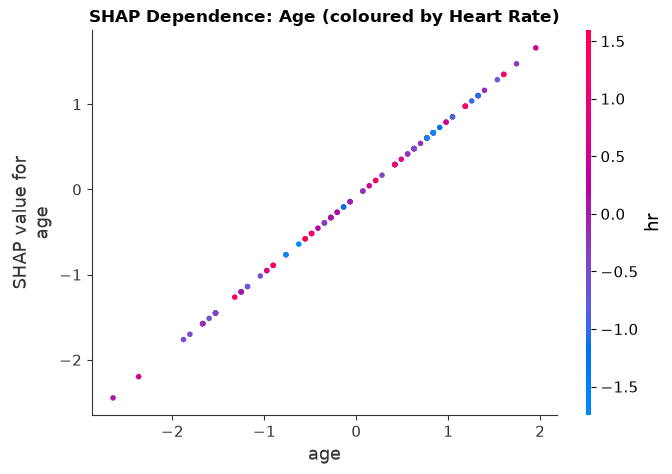

Correlation between age SHAP value and heart rate: 0.041
-> Weak or negligible interaction on this test set: the age effect on
   risk does not meaningfully change with heart rate here. Note this is
   only 100 test patients -- worth rechecking on the full dataset before
   concluding there truly is no interaction.


In [8]:
plot_shap_dependence(
    shap_values, X_test,
    feature='age',
    interaction_feature='hr',
    title='SHAP Dependence: Age (coloured by Heart Rate)'
)
plt.show()

# Quantify the interaction rather than just asking about it: correlate
# age's SHAP contribution against the patient's heart rate.
age_shap = shap_values[:, list(X_test.columns).index('age')]
interaction_corr = np.corrcoef(age_shap, X_test['hr'].values)[0, 1]
print(f'Correlation between age SHAP value and heart rate: {interaction_corr:.3f}')
if abs(interaction_corr) < 0.15:
    print('-> Weak or negligible interaction on this test set: the age effect on')
    print('   risk does not meaningfully change with heart rate here. Note this is')
    print('   only 100 test patients -- worth rechecking on the full dataset before')
    print('   concluding there truly is no interaction.')
else:
    direction = 'higher' if interaction_corr > 0 else 'lower'
    print(f'-> Age pushes risk up more strongly in patients with {direction} heart rate.')